# Laboratory Exercise 5

In [45]:
!pip install ultralytics


### Dataset
- **Source** : Kaggle
- **Format** : Images + annotations
- **Classes**: 1 (`ship`)
- **Resolution per image**: Typically 640x640
- **Dataset size**: 26900 pictures


In [57]:
from ultralytics import YOLO
import os
import random
from PIL import Image
import numpy as np
import cv2
from matplotlib import pyplot as plt

#### Importing dataset and pre-trained model

In [41]:
model = YOLO("yolo11l.pt")

data_path = 'ships-aerial-images/data.yaml'

### Plotting 5 random images from the training dataset

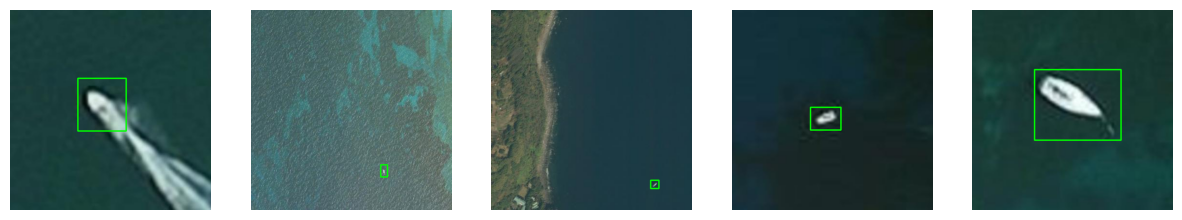

In [64]:
dataset_path="ships-aerial-images/test/images"
annotations_path="ships-aerial-images/test/labels"
def read_annotations(annotation_file, image_width, image_height):
    with open(annotation_file, 'r') as f:
        boxes = []
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            center_x, center_y, width, height = map(float, parts[1:])
            
            xmin = int((center_x - width / 2) * image_width)
            ymin = int((center_y - height / 2) * image_height)
            xmax = int((center_x + width / 2) * image_width)
            ymax = int((center_y + height / 2) * image_height)
            
            boxes.append((xmin, ymin, xmax, ymax))
        return boxes

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for i, image_file in enumerate(random_images):
    image_path = os.path.join(dataset_path, image_file)
    
    image = Image.open(image_path)
    image_width, image_height = image.size
    
    annotation_file = os.path.join(annotations_path, image_file.replace('.jpg', '.txt'))
    boxes = read_annotations(annotation_file, image_width, image_height)
    
    image_np = np.array(image)
    
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        image_np = cv2.rectangle(image_np, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    
    axes[i].imshow(image_np)
    axes[i].axis('off')

plt.show()

### Final training parameterse after couple iterations 

In [5]:
train_params = {
    'epochs': 40,
    'batch': 32,
    'imgsz': 640,
    'lr0': 5e-4,
    'lrf': 0.1,
    'warmup_epochs': 5,
    'warmup_bias_lr': 1e-6,
    'momentum': 0.937,
    'weight_decay': 0.0001,
    'optimizer': 'AdamW',
    'device': '0,1',
    'project': 'runs/train',
    'name': 'vessel_deteciton_v11l',
    'exist_ok': True,
    'save_period': 2,
    'workers': 8,
    'patience': 20,           
    'cos_lr': True,            
}


In [ ]:
model.train(data=data_path, **train_params)

In [42]:
model = YOLO("runs/train/vessel_deteciton_v11l/weights/best.pt")

### Validation

In [4]:
validation = model.val(conf=0.01,iou=0.7, max_det=300, imgsz=640, device='0,1')

Ultralytics 8.3.159 🚀 Python-3.12.3 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24135MiB)
                                                       CUDA:1 (NVIDIA GeForce RTX 3090, 24135MiB)
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 109.2±68.8 MB/s, size: 13.9 KB)


val: Scanning /home/mlmonster/Projects/ferdzo/vesselDetection/ships-aerial-images/valid/labels.cach

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 172, len(boxes) = 3720. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|████


                   all       2165       3720      0.603      0.543      0.551      0.341
Speed: 0.1ms preprocess, 6.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/mlmonster/Projects/ferdzo/vesselDetection/runs/detect/val5


In [ ]:
plt.imshow

### Testing the model on custom images


0: 640x640 2 ships, 7.2ms
1: 640x640 35 ships, 7.2ms
Speed: 0.8ms preprocess, 7.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Confidence: tensor([0.7513, 0.3396], device='cuda:0')
Class IDs: tensor([0., 0.], device='cuda:0')
Number of detections: 2


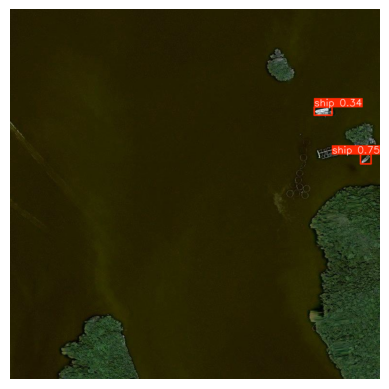

Confidence: tensor([0.7920, 0.7524, 0.7395, 0.7224, 0.7168, 0.7162, 0.7062, 0.6961, 0.6935, 0.6931, 0.6680, 0.6575, 0.6522, 0.6479, 0.6376, 0.6354, 0.6027, 0.5817, 0.5774, 0.5607, 0.5533, 0.5443, 0.5268, 0.5145, 0.4857, 0.4743, 0.4721, 0.4611, 0.4330, 0.3938, 0.3658, 0.3469, 0.3433, 0.3353, 0.3052], device='cuda:0')
Class IDs: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
Number of detections: 35


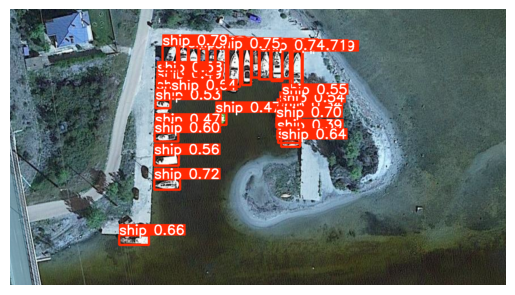

In [43]:
results = model(["5af55.jpg","test.jpg"])

for result in results:
    print(f"Confidence: {result.boxes.conf}")
    print(f"Class IDs: {result.boxes.cls}")
    print(f"Number of detections: {len(result.boxes)}") 
    plt.imshow(result.plot())
    plt.axis('off')
    plt.show()

In [ ]:
model.export(format='onnx')